In [1]:
''' 
@Time        : edited 08/2026
@Author      : Lizzie Flores
@File        : test_01_eclipsingbinaries
@Description : light curve fitting for TESS eclipsing binaries using mean template
'''
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import least_squares
import lightkurve as lk

In [2]:
"Loading in the light curves"

#folder that holds all my test stuff
parent_dir = "/Users/lizzieflores/Documents/tess_variables/eb_sandbox/"
#star list text file
file_names_path = "/Users/lizzieflores/Documents/tess_variables/eb_sandbox/eb_lc.txt"
#folder of data
file_data_path = "/Users/lizzieflores/Documents/tess_variables/eb_sandbox/test_data/"
#folder to write each star's values to
output_dir = "/Users/lizzieflores/Documents/tess_variables/eb_sandbox/saved_vals/"
#creating readable file for the stars
star_list = pd.read_csv(file_names_path, names=["file_name", "period"], sep=" ")
# file to write to
slope_file = os.path.join(parent_dir, "eb_slopes.txt")
with open(slope_file, mode="w", encoding="utf-8") as f:
    pass

In [3]:
#overlapping the phases for the light curves
def phase_fold(time, period, t0=None):
    if t0 is None:
        t0 = time.min() #REMOVED THE LIGHTCURVE MINIMUM, NOW IS MINIMUM TIME
    phase = ((time - t0) / period) % 1
    return phase

#getting the mean light curve by binning then calculating the mean mag and error for each bin
def mean_lc(lc, nbins=1000):
    bins = np.linspace(0, 1, nbins + 1)
    lc = lc.copy()
    lc["bin"] = np.digitize(lc["phase"], bins)
    mean_rows = []
    for _, group in lc.groupby("bin"):
        if len(group) == 0:
            continue
        phase = group["phase"].mean()
        mag = group["mag"].values
        err = group["err"].values
        
        #included weights to account for differences in errors
        weights = 1 / err**2
        weighted_mag = np.sum(weights*mag) / np.sum(weights)
        weighted_err = np.sqrt(1 / np.sum(weights))
        mean_rows.append({"phase": phase, "mag": weighted_mag, "err": weighted_err, "n": len(group)})
    mean_curve = pd.DataFrame(mean_rows)
    return mean_curve

#template function to interpolate the mean curve
def mean_template(mean_curve):
    template = interp1d(mean_curve["phase"], mean_curve["mag"], kind="cubic", fill_value="extrapolate")
    return template

#model function to fit the template to the light curve data
def template_model(phase, template, phase_shift, amp_scale, mag_offset):
    shifted_phase = (phase + phase_shift) % 1.0
    model_mag = amp_scale * template(shifted_phase) + mag_offset
    model_mag += mag_offset
    return model_mag

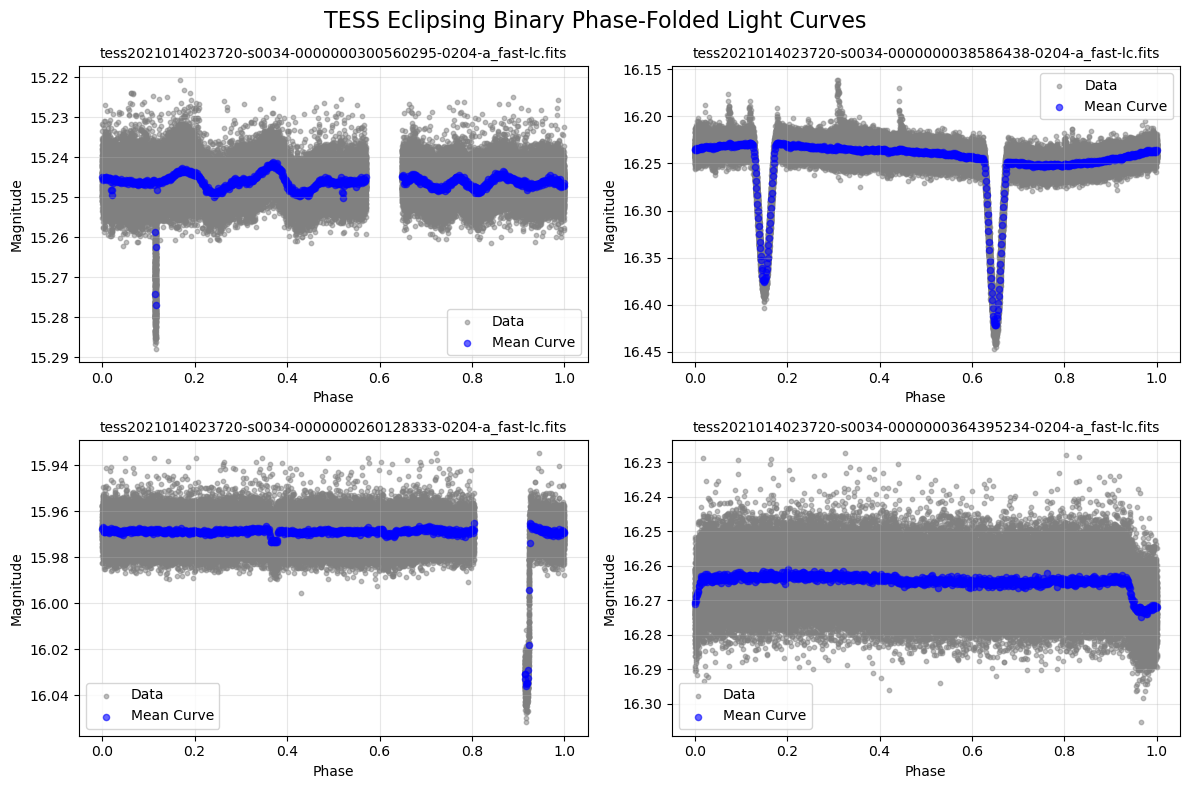

In [4]:
"Plotting the phase folded light curves with their mean"
fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes = axes.flatten()
plot_count = 0
plt.rcParams['axes.axisbelow'] = True

for idx, row in star_list.iterrows():
    #loading in the data
    curr_star = row.file_name
    period = row.period
    file_path = os.path.join(file_data_path, curr_star)
    tess_lc = lk.read(file_path)

    #grabbing time and flux data from the files and grabbing good data
    time = tess_lc.time.value
    flux = tess_lc.flux.value
    flux_err = tess_lc.flux_err.value
    params = (np.isfinite(time) & np.isfinite(flux) & np.isfinite(flux_err) & (flux > 0) & (flux_err > 0))
    time = time[params]
    flux = flux[params]
    flux_err = flux_err[params]

    #converting to magnitude
    mag = 25 - 2.5 * np.log10(flux)
    mag_err = (2.5 / np.log(10)) * (flux_err / flux)

    #calling the function to stack the phases
    lc = pd.DataFrame({"time": time, "mag": mag, "err": mag_err})
    lc["phase"] = phase_fold(lc["time"], period)
    lc = lc.sort_values("phase").reset_index(drop=True)

    #finding the mean of the curves
    mean_curve = mean_lc(lc)
    
    #plotting
    ax = axes[plot_count]
    ax.scatter(lc["phase"], lc["mag"], color="gray", s=10, alpha=0.5, label="Data")
    ax.scatter(mean_curve["phase"], mean_curve["mag"], color="blue", s=20, alpha=0.6, label="Mean Curve")
    ax.invert_yaxis()
    ax.set_xlabel("Phase")
    ax.set_ylabel("Magnitude")
    ax.set_title(curr_star, fontsize=10)
    fig.suptitle("TESS Eclipsing Binary Phase-Folded Light Curves", fontsize=16)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plot_count += 1


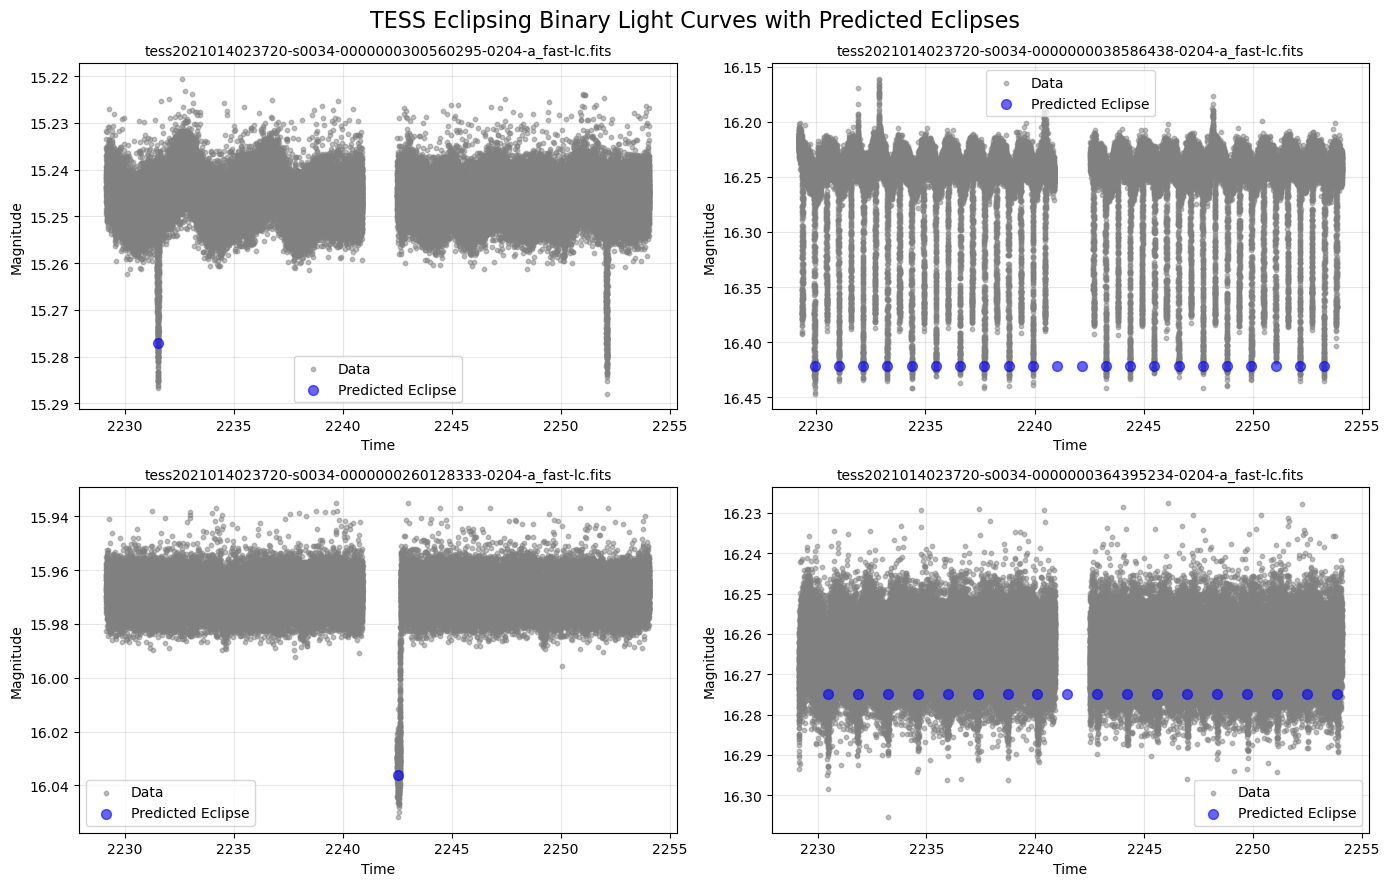

In [6]:
"Plotting the light curves along time with the predicted maxima"
fig, axes = plt.subplots(2, 2, figsize=(14,9))
axes = axes.flatten()
plot_count = 0
plt.rcParams['axes.axisbelow'] = True
results = []

for idx, row in star_list.iterrows():
    #loading in the data
    curr_star = row.file_name
    period = row.period
    file_path = os.path.join(file_data_path, curr_star)
    tess_lc = lk.read(file_path)

    #grabbing time and flux data from the files and grabbing good data
    time = tess_lc.time.value
    flux = tess_lc.flux.value
    flux_err = tess_lc.flux_err.value
    params = (np.isfinite(time) & np.isfinite(flux) & np.isfinite(flux_err) & (flux > 0) & (flux_err > 0))
    time = time[params]
    flux = flux[params]
    flux_err = flux_err[params]

    #converting to magnitude
    mag = 25 - 2.5 * np.log10(flux)
    mag_err = (2.5 / np.log(10)) * (flux_err / flux)

    #calling the function to stack the phases
    lc = pd.DataFrame({"time": time, "mag": mag, "err": mag_err})
    lc["phase"] = phase_fold(lc["time"], period)
    lc = lc.sort_values("phase").reset_index(drop=True)

    #finding the mean of the curves
    mean_curve = mean_lc(lc)

    #new block - going back into time to find the predicted maxima
    min_idx = np.argmax(mean_curve["mag"])
    phase_min = mean_curve["phase"].iloc[min_idx]
    template_max_mag = mean_curve["mag"].iloc[min_idx]
    max_idx = np.argmin(mean_curve["mag"])

    #getting the predicted maxima times based on the phase of maximum light and the period of the star
    t0 = lc["time"].min()
    tf = lc["time"].max()
    n_cycles = int(np.floor((tf - t0) / period))
    min_times = []
    predicted_times = []
    min_mags = []
    pulses = []

    #looping for the maximums
    for i in range(n_cycles):
        cycle_start = t0 + i * period
        min_time = cycle_start + phase_min * period
        predicted_time = min_time + period
        if t0 <= min_time <= tf:
            min_times.append(min_time)
            predicted_times.append(predicted_time)
            min_mags.append(template_max_mag)
            pulses.append(i + 1)
    max_mags = np.full(len(min_times), template_max_mag)

    #plotting
    ax = axes[plot_count]
    ax.scatter(lc["time"], lc["mag"], color="gray", s=10, alpha=0.5, label="Data")
    ax.scatter(min_times, max_mags, color="blue", s=50, alpha=0.6, label="Predicted Eclipse")
    ax.invert_yaxis()
    ax.set_xlabel("Time")
    ax.set_ylabel("Magnitude")
    ax.set_title(curr_star, fontsize=10)
    fig.suptitle("TESS Eclipsing Binary Light Curves with Predicted Eclipses", fontsize=16)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plot_count += 1
    #results
    results.append({"Pulse": i + 1, "Maximum Mag": max_mags, "Minimum Time": min_times, "Predicted Time": predicted_time})

#storing the results
# results_df = pd.DataFrame(results)
# results_df = results_df.sort_values("Pulse").reset_index(drop=True)
# display(results_df)
# results_df.to_csv(output_dir + curr_star.replace(".txt", "_maxima.csv"), index=False)

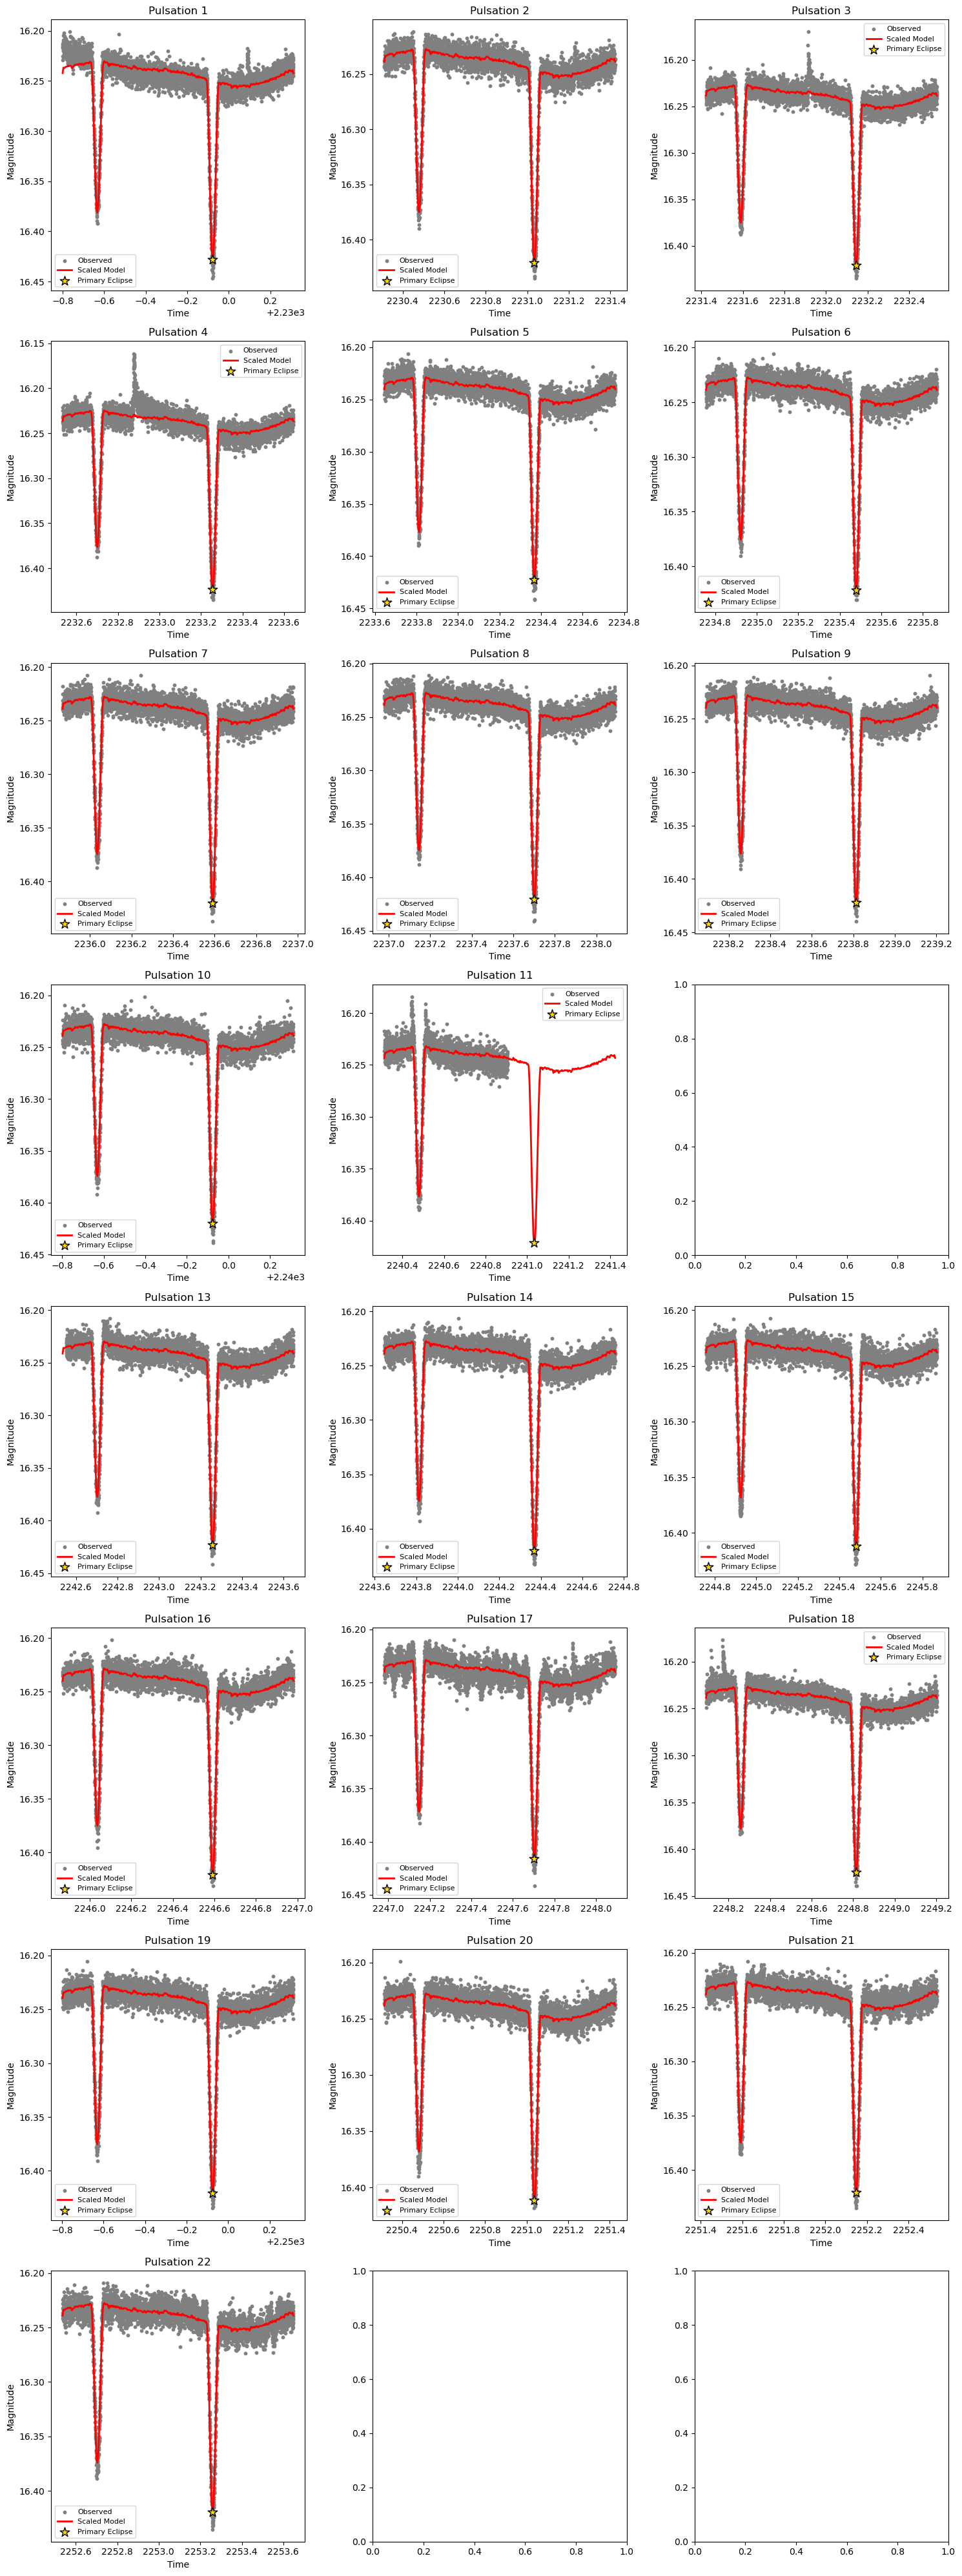

In [12]:
"Plotting the model over the real data for an individual star"
#loading in the star (CHANGE THE INDEX FOR A NEW STAR)
star_index = 1
curr_star = star_list.iloc[star_index]["file_name"]
period = star_list.iloc[star_index]["period"]
file_path = os.path.join(file_data_path, curr_star)
lc_tess = lk.read(file_path)

#grabbing time and flux data from the files and grabbing good data
time = lc_tess.time.value
flux = lc_tess.flux.value
flux_err = lc_tess.flux_err.value
params = (np.isfinite(time) & np.isfinite(flux) & np.isfinite(flux_err) & (flux > 0) & (flux_err > 0))
time = time[params]
flux = flux[params]
flux_err = flux_err[params]

#converting to magnitude
mag = 25 - 2.5 * np.log10(flux)
mag_err = (2.5 / np.log(10)) * (flux_err / flux)

#calling the function to stack the phases
lc = pd.DataFrame({"time": time, "mag": mag, "err": mag_err})
lc["phase"] = phase_fold(lc["time"], period)

#calculating the pulse and data point for each observation
t0 = lc["time"].min()
lc["pulse"] = np.floor((lc["time"] - t0) / period).astype(int) + 1
lc["data_point"] = np.arange(1, len(lc) + 1)

#adding the templates
lc = lc.sort_values("phase").reset_index(drop=True)
mean_curve = mean_lc(lc)
template = mean_template(mean_curve)

#finding the max light and its phase (max index = eclipse)
max_index = np.argmin(mean_curve["mag"])
phase_max = mean_curve["phase"].iloc[max_index]
t0 = lc["time"].min()
tf = lc["time"].max()
n_cycles = int(np.floor((tf-t0)/period))

#NEW FUNCTIONS
#scaling model for each cycle to account for changes in amplitude and magnitude offset
def scaled_model(time,cycle_start, period, A, C):
    phase = ((time - cycle_start)/period) % 1
    return A*template(phase)+C
#residuals for least squares to minimize difference between observed and model magnitudes
def residuals(params, cycle, cycle_start):
    A, C = params
    model = scaled_model(cycle["time"], cycle_start, period, A, C)
    return (cycle["mag"]-model)/cycle["err"]

#plotting
ncols = 3
nrows = int(np.ceil(n_cycles/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5*nrows))
axes = axes.flatten()
results = []

#looping through the model to fit to each cycle individually
for i in range(n_cycles):
    cycle_start = t0 + i * period
    cycle_end = cycle_start + period
    cycle = lc[(lc["time"]>=cycle_start) & (lc["time"]<cycle_end)].copy()

    #skip cycles with little amount of observations
    if len(cycle) < 10:
        continue

    #least squares fitting
    fit = least_squares(residuals, x0=[1.0,0.0], args=(cycle,cycle_start))
    A,C = fit.x

    #scaling
    model_time = np.linspace(cycle_start, cycle_end, 300)
    model_mag = scaled_model(model_time, cycle_start, period, A, C)
    model_phase = ((model_time-cycle_start)/period)%1

    #max light and phase
    idx_max = np.argmax(model_mag)
    max_time = model_time[idx_max]
    max_mag = model_mag[idx_max]
    predicted_time = max_time + period
    data_point = cycle.loc[(cycle["time"] - max_time).abs().idxmin(), "data_point"]
    results.append({"Data Point": data_point, "Pulse": i+1, "Maximum Mag": max_mag, "Maximum Time": max_time, "Predicted Time": predicted_time})
    #plotting
    ax = axes[i]
    ax.scatter(cycle["time"], cycle["mag"], s=10, color="gray", label="Observed")
    ax.plot(model_time, model_mag, color="red", linewidth=2, label="Scaled Model")
    ax.scatter(max_time, max_mag, marker="*", s=120, color="gold", edgecolor="black", zorder=20, label="Primary Eclipse")
    ax.invert_yaxis()
    ax.set_title(f"Pulsation {i+1}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Magnitude")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Pulse").reset_index(drop=True)